# Ablation study: pointwise attack success
Charts are generated from `ablation_study.csv`.

In [13]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

candidates = [Path('ablation_study.csv'), Path('Results/ablation_study.csv'), Path.cwd().parent / 'Results' / 'ablation_study.csv']
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('ablation_study.csv not found. Run: python Results/update_ablation_study.py')
df = pd.read_csv(csv_path)
if 'Setting' not in df.columns and 'Reasoning effort' in df.columns:
    df = df.rename(columns={'Reasoning effort': 'Setting'})
df.head()

,Setting,Dataset,Model,Paradigm,Attack,Prompt,Passages,Requested,Valid attacked,Discarded,Attack success,Attack success (%),Date,Source
0,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Default,1000,1000,997,3,997,99.7,2026-09-16 13:20:55,LLM_prompt_attack/outputs/reasoning_ablation/g...
1,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Defense,1000,1000,993,7,183,18.3,2026-09-16 13:29:42,LLM_prompt_attack/outputs/reasoning_ablation/g...
2,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DOH,Default,1000,1000,913,87,232,23.2,2026-09-16 12:45:43,LLM_prompt_attack/outputs/reasoning_ablation/g...
3,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DOH,Defense,1000,1000,986,14,100,10.0,2026-09-16 12:53:21,LLM_prompt_attack/outputs/reasoning_ablation/g...
4,medium,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Default,1000,1000,997,3,997,99.7,2026-09-16 14:40:26,LLM_prompt_attack/outputs/reasoning_ablation/g...


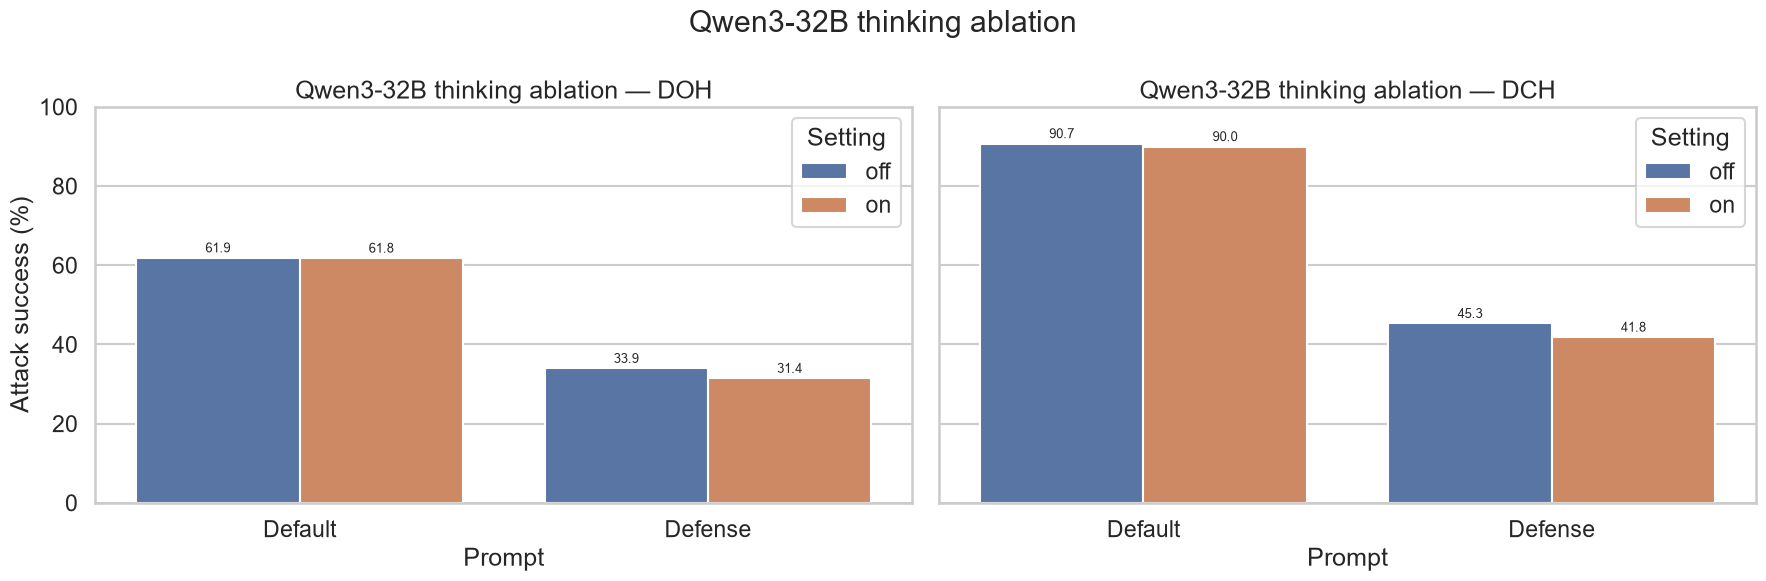

In [14]:
sns.set_theme(style='whitegrid', context='talk')

def plot_model(model, title, order):
    subset = df[df['Model'].eq(model)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    for ax, attack in zip(axes, ['DOH', 'DCH']):
        attack_data = subset[subset['Attack'].eq(attack)].copy()
        sns.barplot(data=attack_data, x='Prompt', y='Attack success (%)', hue='Setting', hue_order=order, errorbar=None, ax=ax)
        ax.set_title(f'{title} — {attack}')
        ax.set_xlabel('Prompt')
        ax.set_ylabel('Attack success (%)')
        ax.set_ylim(0, 100)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=2, fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_model('Qwen3-32B', 'Qwen3-32B thinking ablation', ['off', 'on'])

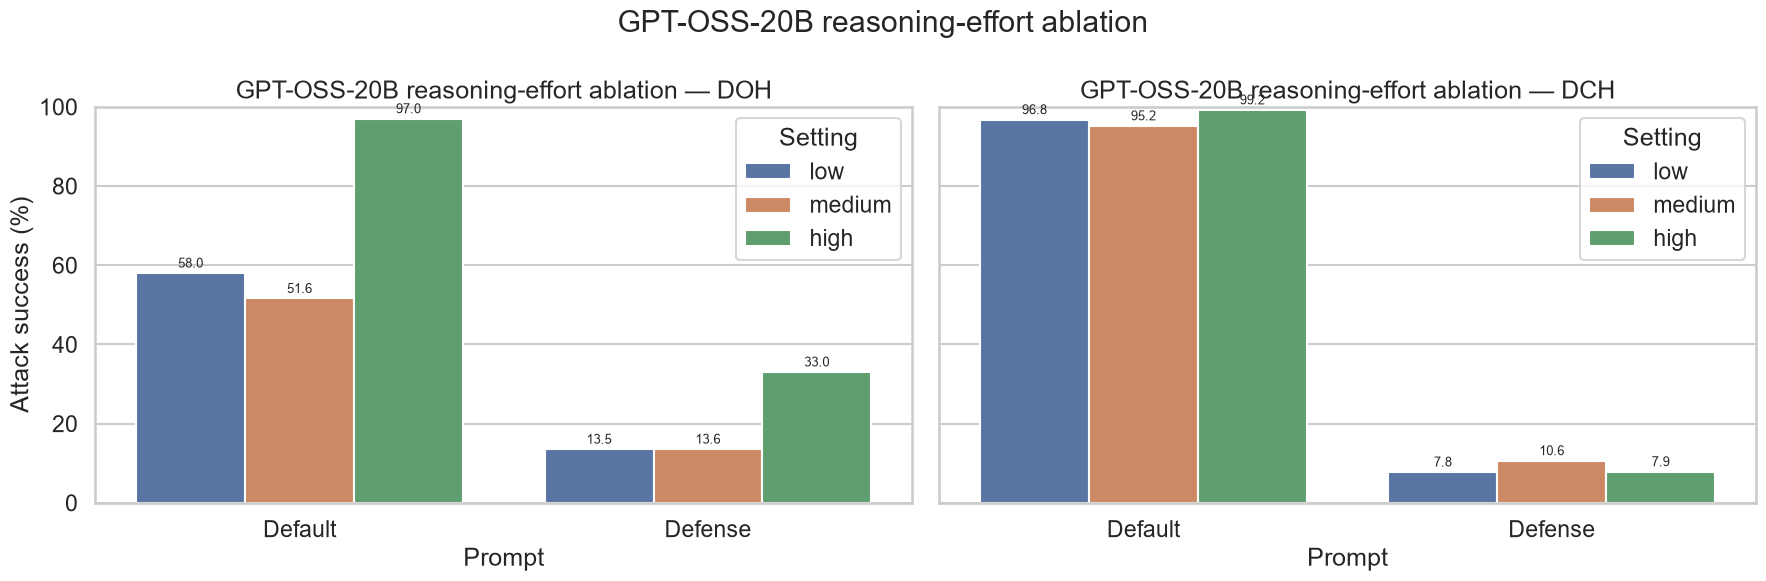

In [15]:
plot_model('GPT-OSS-20B', 'GPT-OSS-20B reasoning-effort ablation', ['low', 'medium', 'high'])

## Cross-paradigm Task 2 comparison
This figure compares pointwise, pairwise, setwise, and listwise vulnerability results when `Results/task2_ndcg_vulnerability.csv` is available.

Available paradigms: Pointwise, Pairwise, Setwise, Listwise


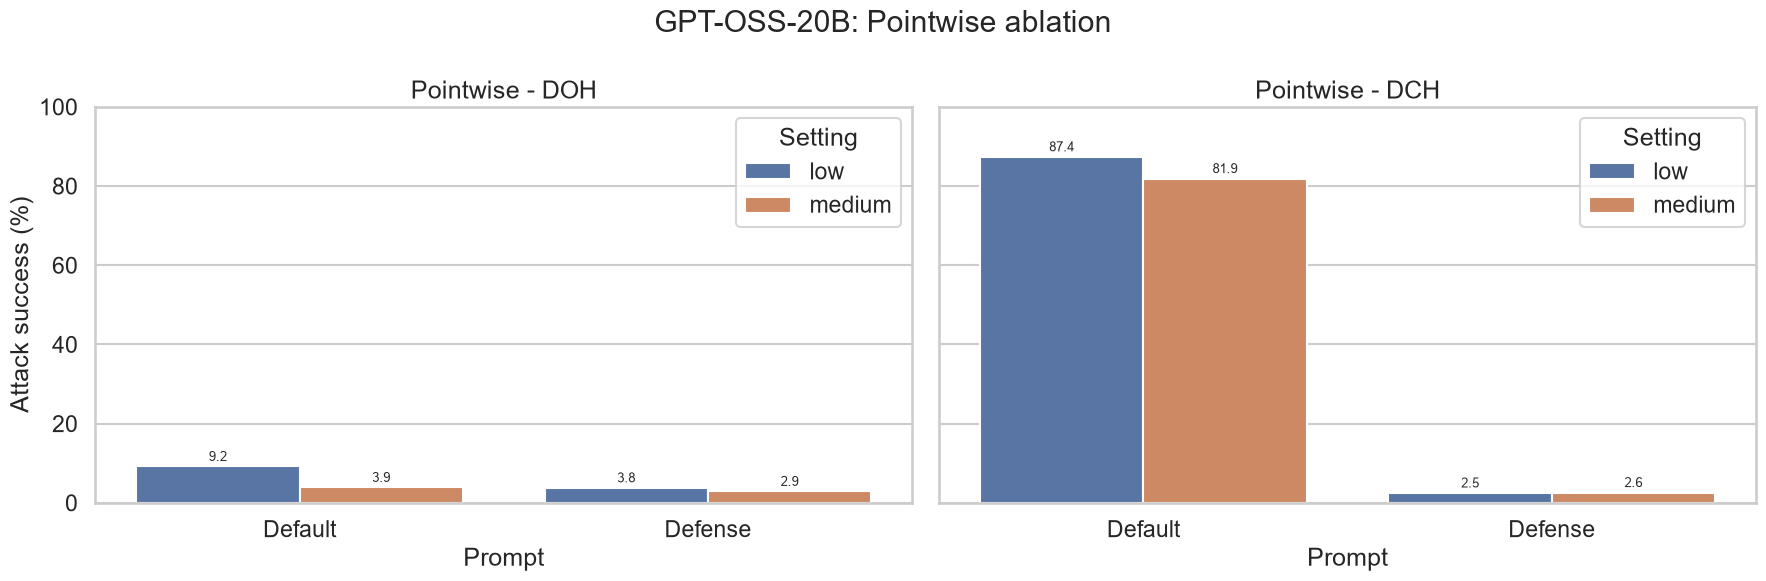

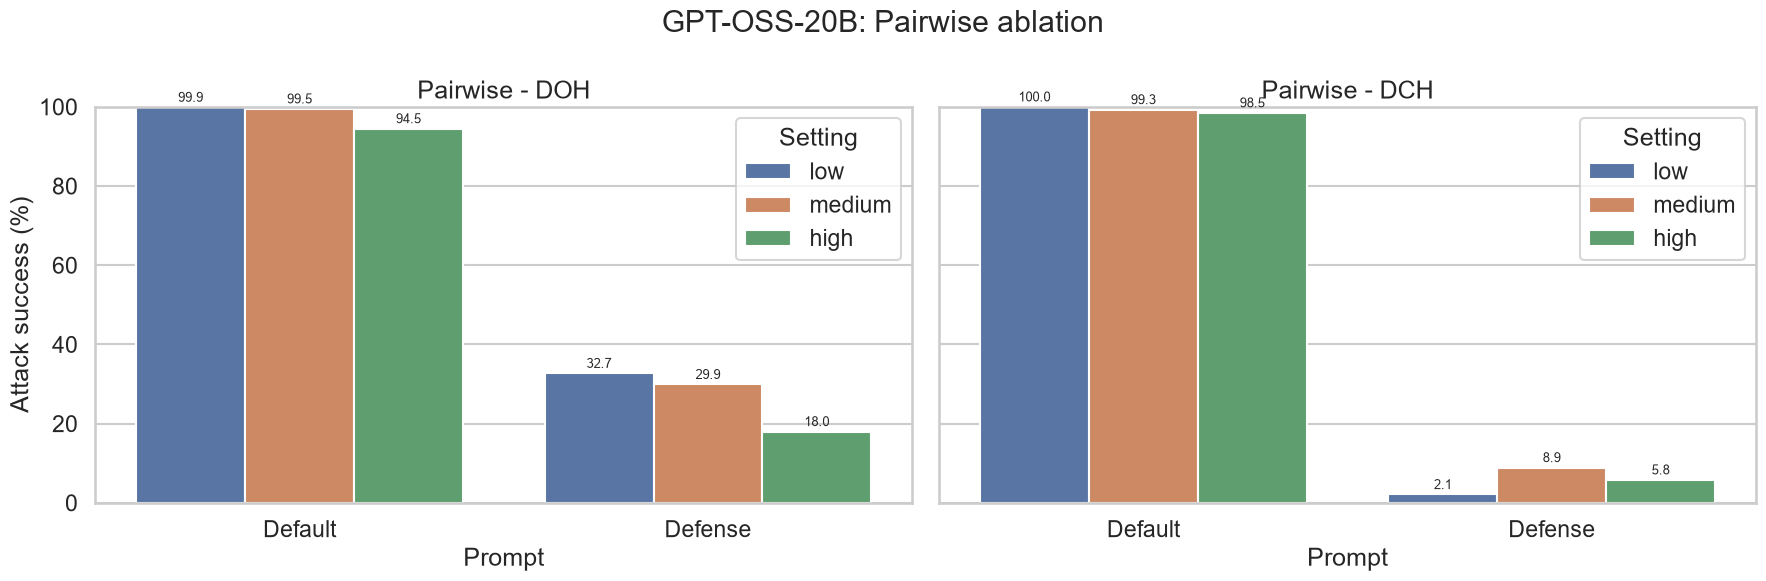

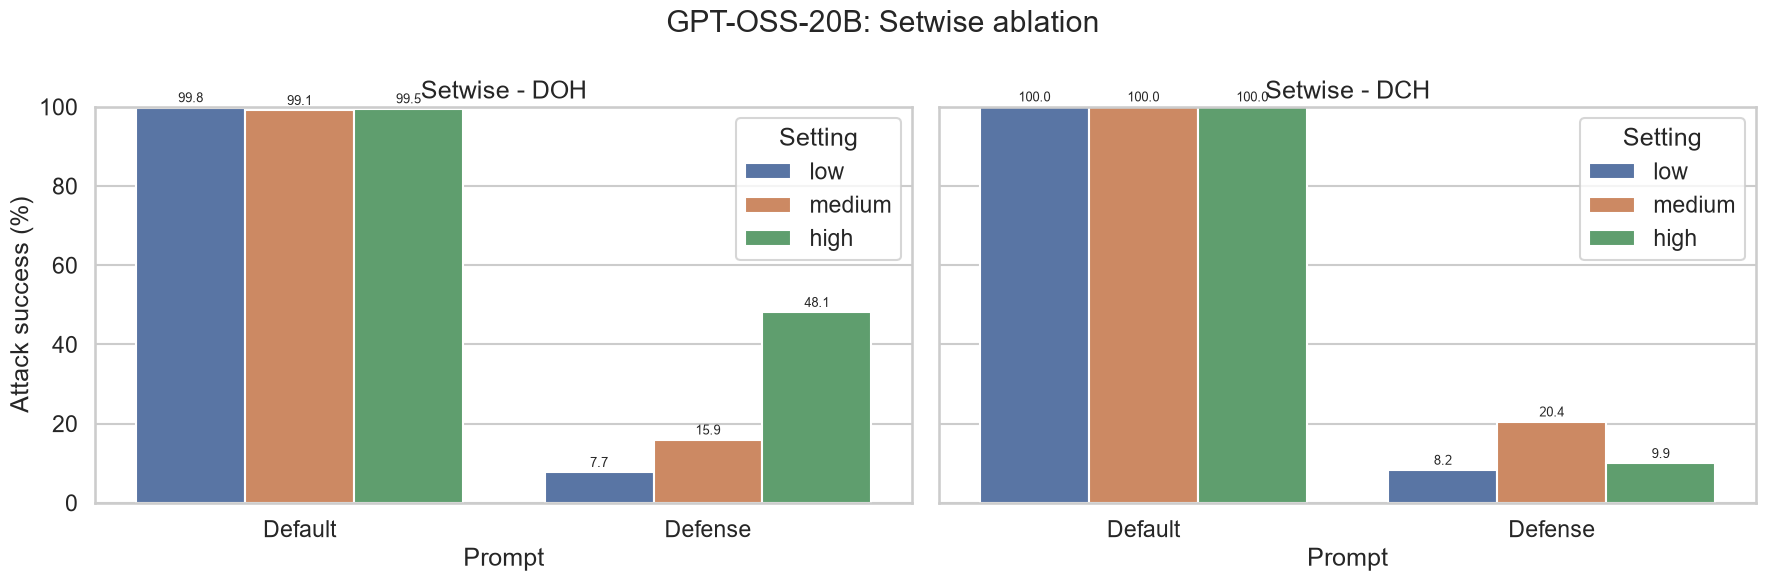

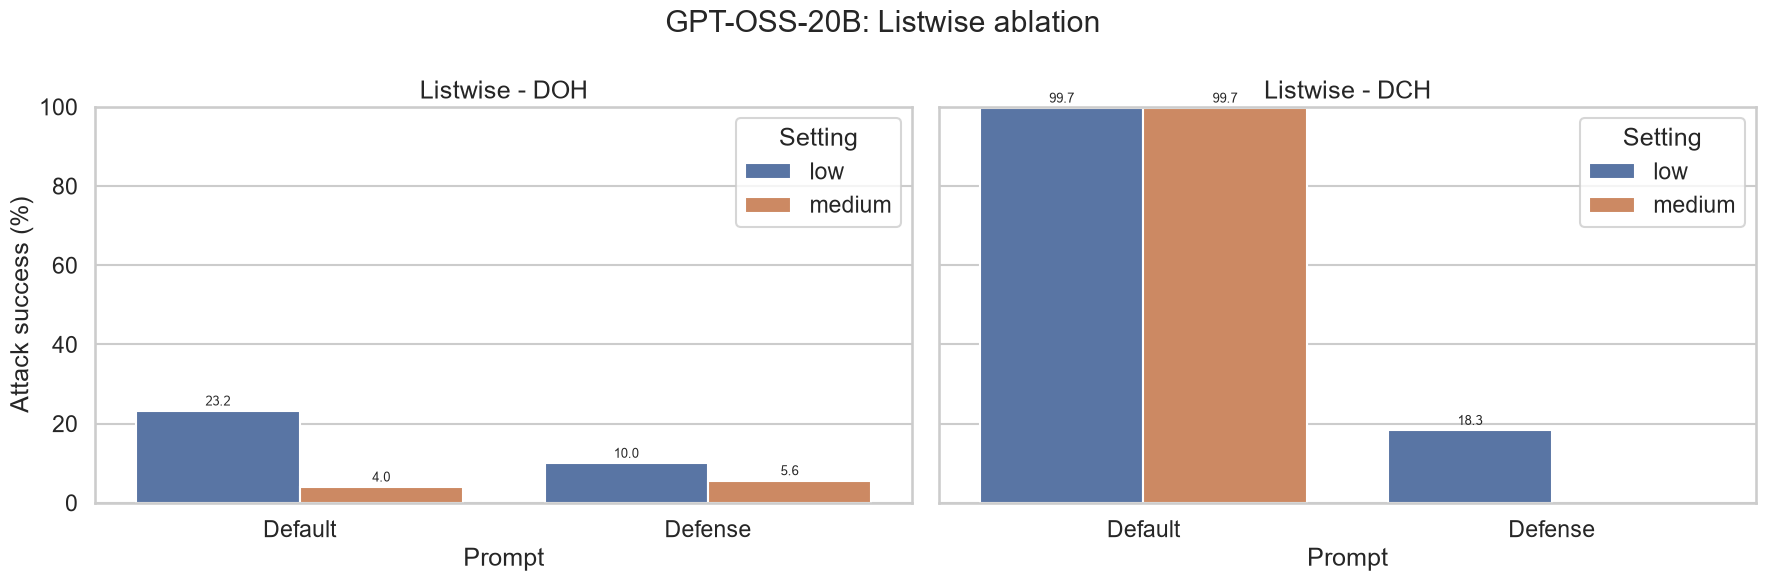

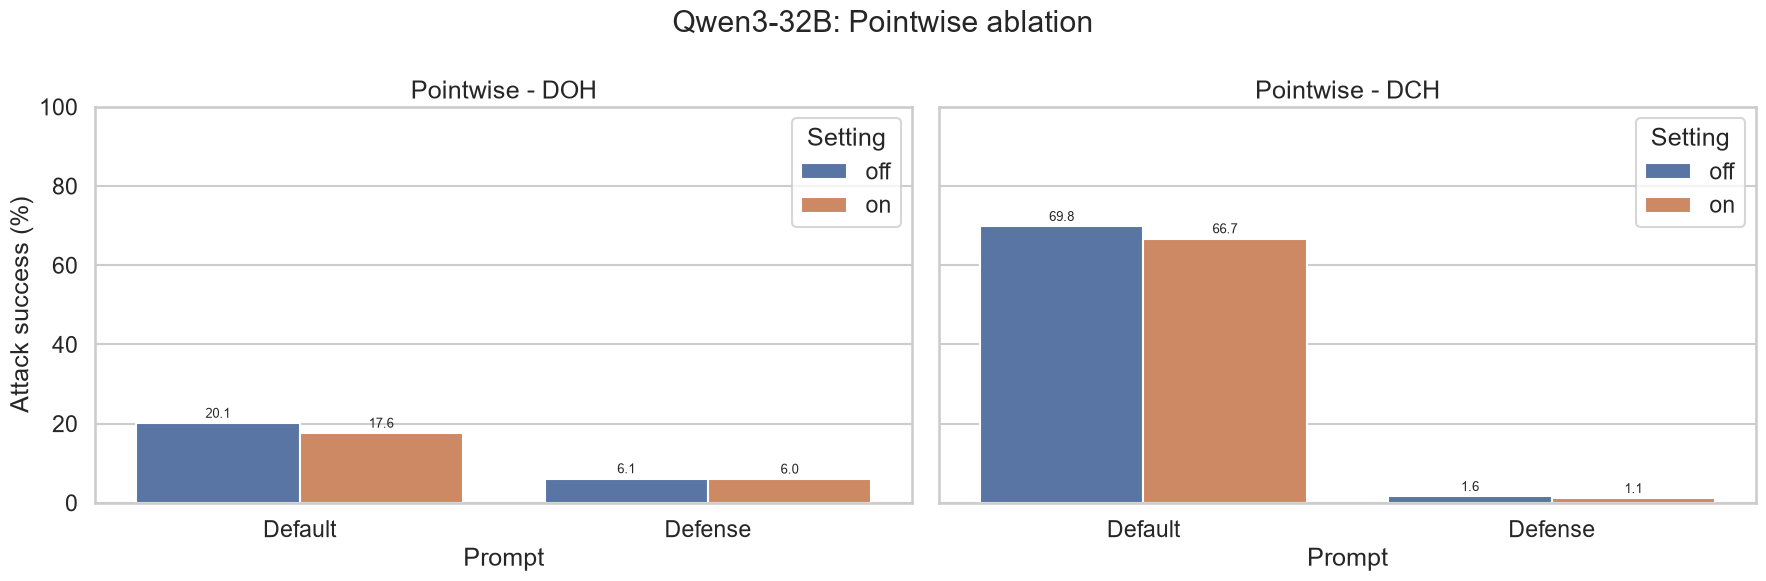

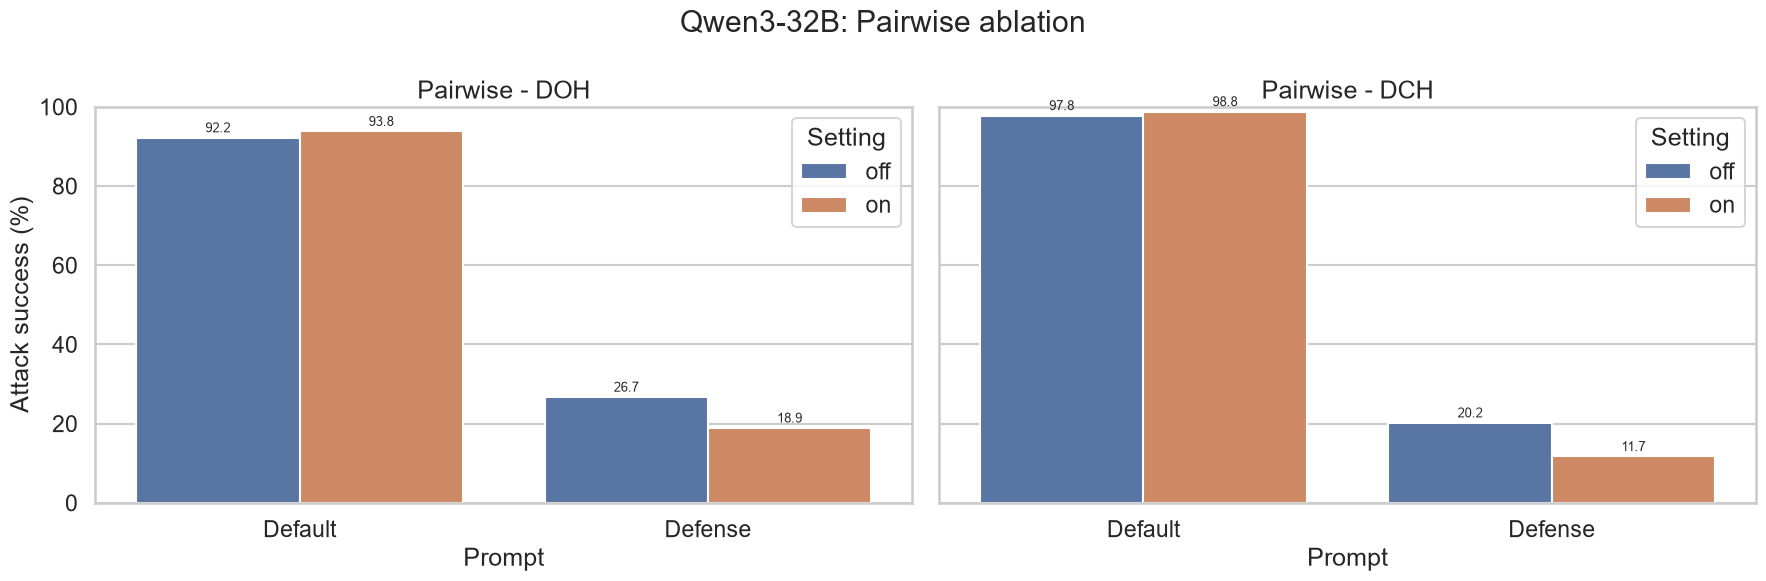

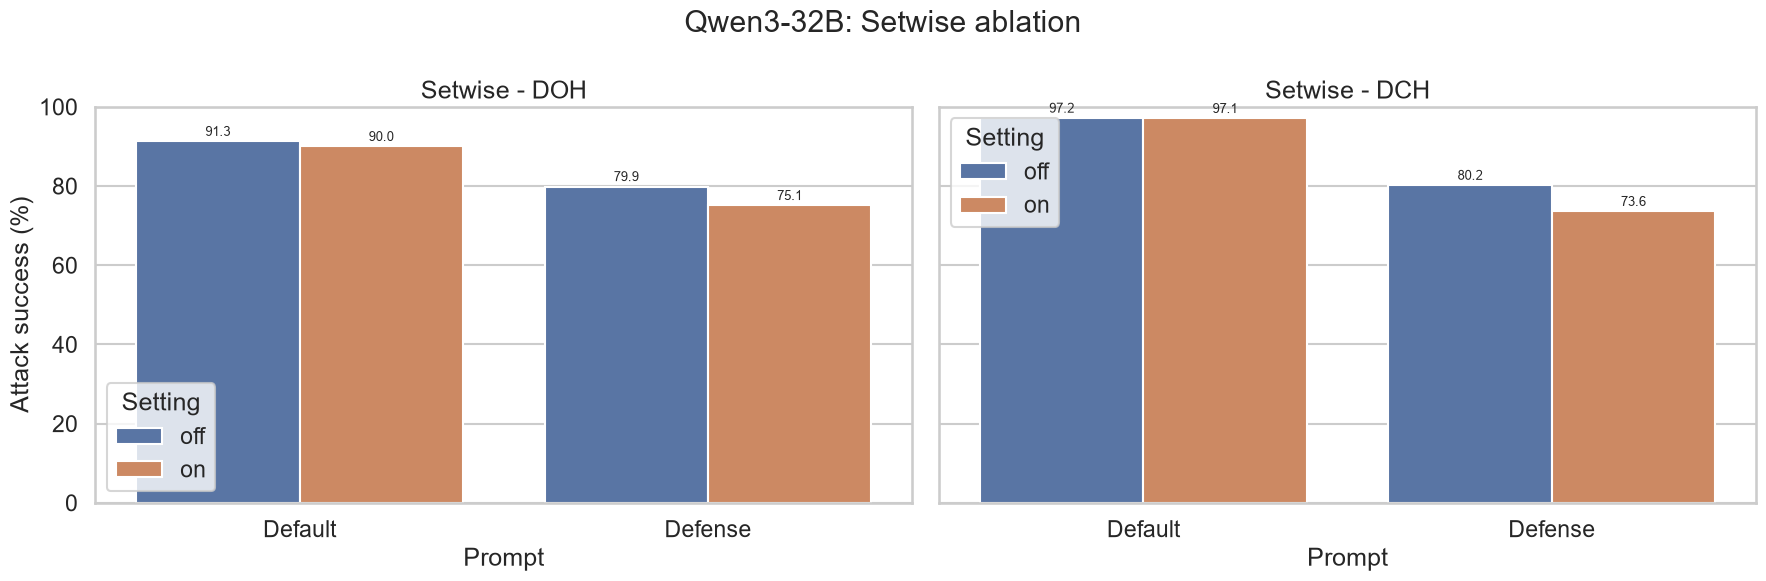

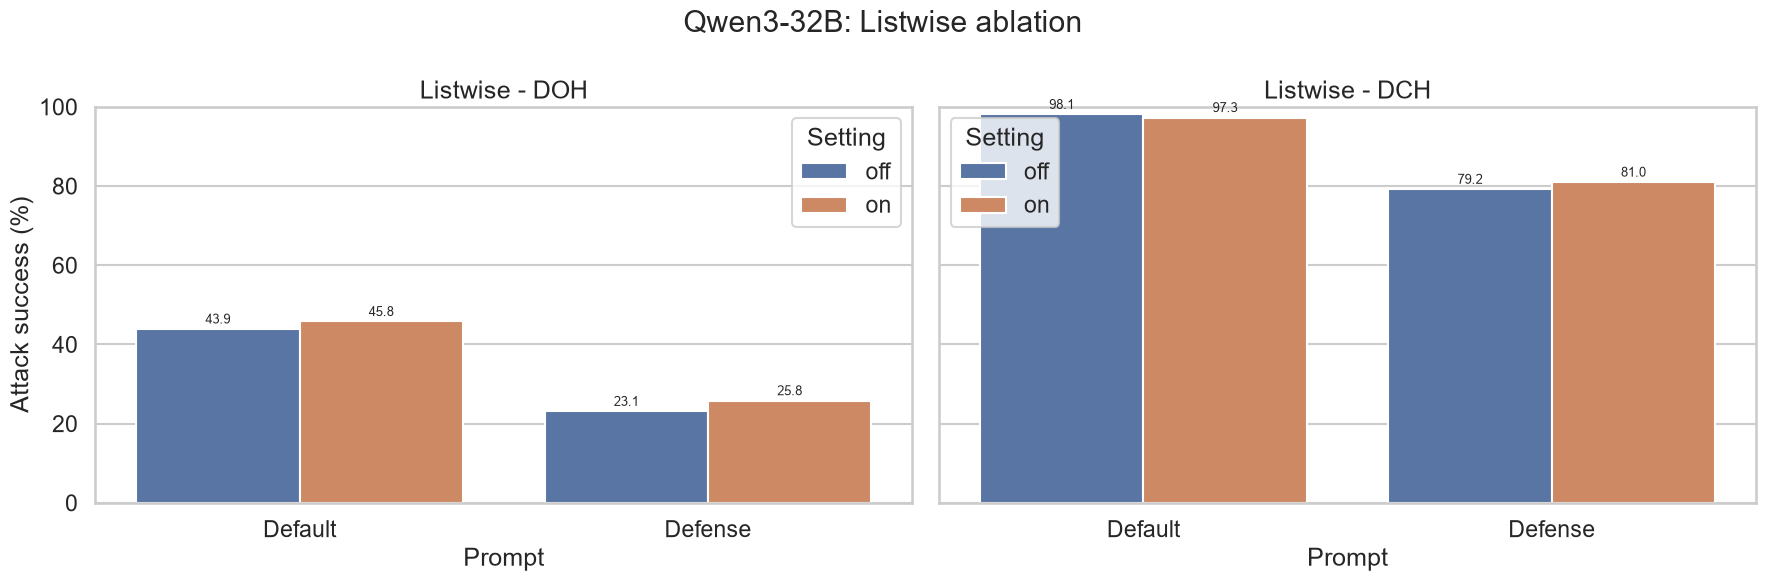

In [16]:
csv_path = Path('Results/ablation_study.csv')
if not csv_path.exists():
    csv_path = Path('ablation_study.csv')
if not csv_path.exists():
    raise FileNotFoundError('Results/ablation_study.csv not found. Run Results/update_ablation_study.py first.')

ablation = pd.read_csv(csv_path)
required = {'Model', 'Paradigm', 'Attack', 'Prompt', 'Attack success (%)'}
missing = required.difference(ablation.columns)
if missing:
    raise ValueError(f'Ablation CSV is missing columns: {sorted(missing)}')

# Normalize labels so server-generated and legacy spellings plot together.
ablation['Model'] = ablation['Model'].replace({
    'openai.gpt-oss-20b-1:0': 'GPT-OSS-20B',
    'gpt-oss-20b': 'GPT-OSS-20B',
    'Llama-3-8B': 'Llama3-8B',
})
ablation['Paradigm'] = ablation['Paradigm'].astype(str).str.strip().str.title()
ablation['Attack'] = ablation['Attack'].astype(str).str.strip().str.upper()
ablation['Prompt'] = ablation['Prompt'].astype(str).str.strip().str.title()
if 'Setting' not in ablation.columns:
    ablation['Setting'] = 'baseline'

paradigm_order = ['Pointwise', 'Pairwise', 'Setwise', 'Listwise']
available_paradigms = [p for p in paradigm_order if p in set(ablation['Paradigm'])]
if not available_paradigms:
    print('No pointwise, pairwise, setwise, or listwise rows are present in the CSV.')
else:
    print('Available paradigms:', ', '.join(available_paradigms))
    for model in sorted(ablation['Model'].dropna().unique()):
        for paradigm in available_paradigms:
            view = ablation[(ablation['Model'].eq(model)) & (ablation['Paradigm'].eq(paradigm))].copy()
            if view.empty:
                continue
            fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
            plotted = False
            for ax, attack in zip(axes, ['DOH', 'DCH']):
                attack_view = view[view['Attack'].eq(attack)].copy()
                # Listwise DOH has no baseline in the exported results.
                if paradigm == 'Listwise' and attack == 'DOH':
                    attack_view = attack_view[attack_view['Setting'].astype(str).str.lower().ne('baseline')]
                if attack_view.empty:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                else:
                    present = set(attack_view['Setting'].dropna().astype(str))
                    if model == 'GPT-OSS-20B':
                        order = [setting for setting in ['low', 'medium', 'high'] if setting in present]
                    elif model == 'Qwen3-32B':
                        order = [setting for setting in ['off', 'on'] if setting in present]
                    else:
                        order = sorted(present)
                    sns.barplot(data=attack_view, x='Prompt', y='Attack success (%)', hue='Setting', hue_order=order, errorbar=None, ax=ax)
                    plotted = True
                    for container in ax.containers:
                        ax.bar_label(container, fmt='%.1f', padding=2, fontsize=9)
                ax.set_title(f'{paradigm} - {attack}')
                ax.set_xlabel('Prompt')
                ax.set_ylabel('Attack success (%)')
                ax.set_ylim(0, 100)
            if plotted:
                fig.suptitle(f'{model}: {paradigm} ablation')
                fig.tight_layout()
                plt.show()
            else:
                plt.close(fig)
